# SVD and PCA

SVD stands for Singular Value Decomposition, which is a mathematical technique used in linear algebra to factorize a matrix into three other matrices. It is widely used in various applications such as signal processing, statistics, and machine learning.

PCA stands for Principal Component Analysis, which is a statistical procedure that uses SVD to transform a set of correlated variables into a set of uncorrelated variables called principal components. PCA is commonly used for dimensionality reduction, data visualization, and feature extraction in machine learning.

## SVD - Mathematical Basics
Given a matrix $( A )$ of size $( m \times n )$, the SVD of $( A )$ can be expressed as:

$A = U \Sigma V^T$

Where:
- $( U )$ is an $( m \times m )$ orthogonal matrix whose columns are the left singular vectors of $( A )$.
- $( \Sigma )$ is an $( m \times n )$ diagonal matrix with non-negative real numbers on the diagonal, known as singular values.
- $( V^T )$ is the transpose of an $( n \times n )$
orthogonal matrix whose columns are the right singular vectors of $( A )$.

In practice, the singular values in \( \Sigma \) are often arranged in descending order, and the number of non-zero singular values corresponds to the rank of the matrix \( A \).

In simple terms, SVD breaks the original matrix into three components. These three components are: U, which represents the left singular vectors; Σ, which contains the singular values; and V^T, which represents the right singular vectors. This decomposition allows us to analyze the structure of the matrix and can be used for various applications such as noise reduction, data compression, and more. 

## PCA - Mathematical Basics
PCA is a technique that transforms the original data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on.

PCA can be performed using SVD. Given a data matrix \( X \) of size \( m \times n \) (where \( m \) is the number of samples and \( n \) is the number of features), we can center the data by subtracting the mean of each feature. Then, we can compute the SVD of the centered data matrix:
$X_{centered} = U \Sigma V^T$

The principal components are given by the columns of \( V \), and the singular values in \( \Sigma \) indicate the amount of variance captured by each principal component. The first few principal components can be selected to reduce the dimensionality of the data while retaining most of the variance.



In [1]:
# canonical example of PCA used for dimensionality reduction

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

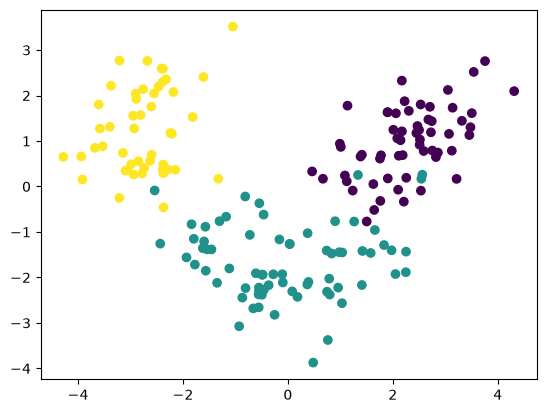

In [2]:

from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
pca = PCA(n_components=3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)

In [3]:
X_reconstructed = pca.inverse_transform(X_2d)
X_reconstructed = scaler.inverse_transform(X_reconstructed)
error = ((X_scaled - X_reconstructed) ** 2).mean()
error

np.float64(49326.38068765999)

In [4]:
X.iloc[0], X_reconstructed[0]

(alcohol                           14.23
 malic_acid                         1.71
 ash                                2.43
 alcalinity_of_ash                 15.60
 magnesium                        127.00
 total_phenols                      2.80
 flavanoids                         3.06
 nonflavanoid_phenols               0.28
 proanthocyanins                    2.29
 color_intensity                    5.64
 hue                                1.04
 od280/od315_of_diluted_wines       3.92
 proline                         1065.00
 Name: 0, dtype: float64,
 array([1.39811436e+01, 1.77567072e+00, 2.46107463e+00, 1.64628284e+01,
        1.12300314e+02, 3.15551246e+00, 3.39678913e+00, 2.40623111e-01,
        2.20247206e+00, 6.19979282e+00, 1.08667086e+00, 3.30742755e+00,
        1.21755395e+03]))

In [5]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=10)
X_dim_red = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_dim_red)

error = ((X_scaled - X_reconstructed) ** 2).mean(axis=0)

print(error)

[0.02351431 0.00389004 0.05862928 0.05326645 0.00213407 0.05874638
 0.07206457 0.00473248 0.01567523 0.06185903 0.01270011 0.06397723
 0.06674764]


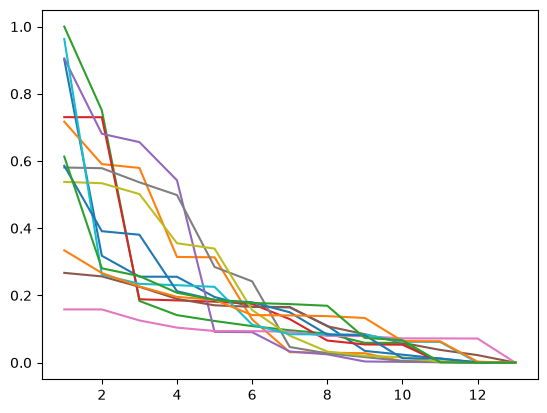

In [6]:
import matplotlib.pyplot as plt
errors = []
for n in range(1, 14):
    pca = PCA(n_components=n)
    X_dim_red = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_dim_red)
    error = ((X_scaled - X_reconstructed) ** 2).mean(axis=0)
    errors.append(error)

plt.plot(range(1, 14), errors)
plt.show()

Another example, now with iris

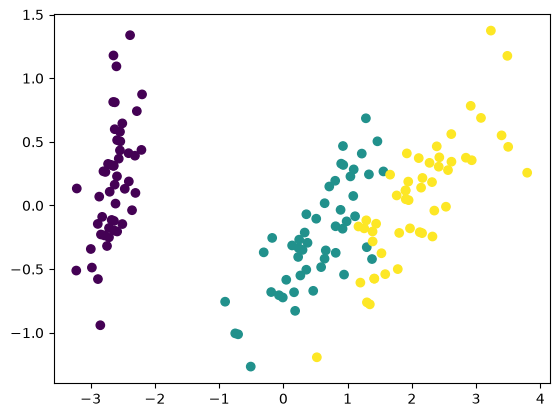

In [7]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

n_components = 2
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)